In [7]:


import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Step 1: DATA LOADING AND INITIAL EXPLORARTION

customers=pd.read_csv("customers.csv")
orders=pd.read_csv("orders.csv")
order_item=pd.read_csv("order_item.csv")
payments=pd.read_csv("payments.csv")
reviews=pd.read_csv("reviews.csv")
products=pd.read_csv("products.csv")
sellers=pd.read_csv("sellers.csv")
category_translation=pd.read_csv("category_translation.csv")
location=pd.read_csv("location.csv")


#Inspect structure using .head(), .info(), .describe() 
customers.head()
customers.info()
customers.describe()

orders.head()
orders.info()
orders.describe()


order_item.head()
order_item.info()
order_item.describe()

payments.head()
payments.info()
payments.describe()

reviews.head()
reviews.info()
reviews.describe()


products.head()
products.info()
products.describe()

sellers.head()
sellers.info()
sellers.describe()

category_translation.head()
category_translation.info()
category_translation.describe()

location.head()
location.info()
location.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [1]:

#2.Step 2: Data Cleaning and Preprocessing


In [8]:
#Missing values
print(customers.isna().sum())
print(orders.isna().sum())
print(order_item.isna().sum())
print(payments.isna().sum())
print(reviews.isna().sum())
print(products.isna().sum())
print(sellers.isna().sum())
print(category_translation.isna().sum())
print(location.isna().sum())

#Remove duplicate records
customers.drop_duplicates(inplace=True)
orders.drop_duplicates(inplace=True)
order_item.drop_duplicates(inplace=True)
payments.drop_duplicates(inplace=True)
reviews.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
sellers.drop_duplicates(inplace=True)
order_item.drop_duplicates(inplace=True)
category_translation.drop_duplicates(inplace=True)
location.drop_duplicates(inplace=True)

print(customers.duplicated().sum())
print(orders.duplicated().sum())
print(order_item.duplicated().sum())
print(payments.duplicated().sum())
print(reviews.duplicated().sum())
print(products.duplicated().sum())
print(sellers.duplicated().sum())
print(category_translation.duplicated().sum())
print(location.duplicated().sum())


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date    

In [15]:
#These are date-time columns. The possible reason for missing values is due to order cancellation, not delivered yet, or carrier not assigned, so converting date columns to datetime format 

In [9]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])

orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
    
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
    
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])


print(orders['order_purchase_timestamp'] )    
print(orders['order_approved_at'])
print(orders['order_delivered_carrier_date'])
print(orders['order_delivered_customer_date'])
print(orders['order_estimated_delivery_date'])

0       2017-10-02 10:56:33
1       2018-07-24 20:41:37
2       2018-08-08 08:38:49
3       2017-11-18 19:28:06
4       2018-02-13 21:18:39
                ...        
99436   2017-03-09 09:54:05
99437   2018-02-06 12:58:58
99438   2017-08-27 14:46:43
99439   2018-01-08 21:28:27
99440   2018-03-08 20:57:30
Name: order_purchase_timestamp, Length: 99441, dtype: datetime64[ns]
0       2017-10-02 11:07:15
1       2018-07-26 03:24:27
2       2018-08-08 08:55:23
3       2017-11-18 19:45:59
4       2018-02-13 22:20:29
                ...        
99436   2017-03-09 09:54:05
99437   2018-02-06 13:10:37
99438   2017-08-27 15:04:16
99439   2018-01-08 21:36:21
99440   2018-03-09 11:20:28
Name: order_approved_at, Length: 99441, dtype: datetime64[ns]
0       2017-10-04 19:55:00
1       2018-07-26 14:31:00
2       2018-08-08 13:50:00
3       2017-11-22 13:39:59
4       2018-02-14 19:46:34
                ...        
99436   2017-03-10 11:18:03
99437   2018-02-07 23:22:42
99438   2017-08-28 20:52:26
9

In [23]:
#fill missing review_comment_title and comment messages

In [10]:
reviews['review_comment_title'] = reviews['review_comment_title'].fillna('No Title')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('No Comment')   
reviews.isna().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [12]:
#product category
products['product_category_name']=products['product_category_name'].fillna("unknown")


#replacing numeric column with median

products['product_name_lenght'] = products['product_name_lenght'].fillna(products['product_name_lenght'].median())

products['product_description_lenght'] = products['product_description_lenght'].fillna(products['product_description_lenght'].median())

products['product_photos_qty'] = products['product_photos_qty'].fillna(products['product_photos_qty'].median())

products['product_weight_g'] = products['product_weight_g'].fillna(products['product_weight_g'].median())

products['product_length_cm'] = products['product_length_cm'].fillna(products['product_length_cm'].median())

products['product_height_cm'] = products['product_height_cm'].fillna(products['product_height_cm'].median())

products['product_width_cm'] = products['product_width_cm'].fillna(products['product_width_cm'].median())


In [13]:
#checking the values are filled or not
orders.isna().sum()
reviews.isna().sum()
products.isna().sum()

print(reviews.head())
print(products.head())
print(orders.head())

                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4             No Title   
1             5             No Title   
2             5             No Title   
3             5             No Title   
4             5             No Title   

                              review_comment_message review_creation_date  \
0                                         No Comment  2018-01-18 00:00:00   
1                                         No Comment  2018-03-10 00:00:00   
2                                         No Comment  2018-02-17 00:00:00   
3           

In [14]:
#check datatypes
orders.dtypes

products.dtypes

order_item.dtypes

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

In [15]:
#here shipping date time stored as text

order_item['shipping_limit_date'] = pd.to_datetime(order_item['shipping_limit_date'])
orders.dtypes    


order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [16]:
#validate ranges
order_item.describe()

payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [17]:
# standardise column names

customers.columns = customers.columns.str.lower().str.replace(" ", "_")
print(customers.columns)
orders.columns = orders.columns.str.lower().str.replace(" ", "_")
print(orders.columns)
order_item.columns = order_item.columns.str.lower().str.replace(" ", "_")
print(order_item.columns)
payments.columns = payments.columns.str.lower().str.replace(" ", "_")
print(payments.columns)
reviews.columns = reviews.columns.str.lower().str.replace(" ", "_")
print(reviews.columns)
products.columns = products.columns.str.lower().str.replace(" ", "_")
print(products.columns)
sellers.columns = sellers.columns.str.lower().str.replace(" ", "_")
print(sellers.columns)
category_translation.columns = category_translation.columns.str.lower().str.replace(" ", "_")
print(category_translation.columns)
location.columns = location.columns.str.lower().str.replace(" ", "_")
print(location.columns)

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')
Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm

In [18]:
#DATA INTEGRATION

#orders and customers

category_translation = pd.read_csv("category_translation.csv")
master_dataset=pd.merge(orders, customers,on='customer_id',how='left')
print(master_dataset)   

# orders + order_items
master_dataset = pd.merge(master_dataset,order_item,on='order_id',how='left') 
print(master_dataset) 

# order_items + products
master_dataset = pd.merge(master_dataset,products,on='product_id',how='left') 
print(master_dataset) 

#orders + payments
master_dataset = pd.merge(master_dataset,payments,on='order_id',how='left') 
print(master_dataset)

#orders + reviews
master_dataset = pd.merge(master_dataset,reviews,on='order_id',how='left') 
print(master_dataset)

# order_items + sellers
master_dataset = pd.merge(master_dataset, sellers,on='seller_id',how='left') 
print(master_dataset)


# products + category_translation
master_dataset = pd.merge(master_dataset, category_translation, on='product_category_name', how='left')

# Display final master dataset
print(master_dataset.head())

# Check shape of dataset
print(master_dataset.shape)

# Save final consolidated dataset
master_dataset.to_csv("master_ecommerce_dataset.csv", index=False)

                               order_id                       customer_id  \
0      e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1      53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2      47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3      949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4      ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                 ...                               ...   
99436  9c5dedf39a927c1b2549525ed64a053c  39bd1228ee8140590ac3aca26f2dfe00   
99437  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
99438  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
99439  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
99440  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

      order_status order_purchase_timestamp   order_approved_at  \
0       

In [25]:
#FEATURE ENGINEERING

#1.	Total order value (aggregated from order_items or payments) 
#price+freight value

master_dataset["total_order_value"]=master_dataset['price'] + master_dataset['freight_value']

print(master_dataset[['price', 'freight_value', 'total_order_value']].head())


#2. Delivery Time
# order delivered date - purchase date

master_dataset['order_purchase_timestamp'] = pd.to_datetime( master_dataset['order_purchase_timestamp'])
   


master_dataset['order_delivered_customer_date'] = pd.to_datetime(  master_dataset['order_delivered_customer_date'])
  

master_dataset['delivery_time'] = (master_dataset['order_delivered_customer_date']  - master_dataset['order_purchase_timestamp']).dt.days
print(master_dataset[['order_purchase_timestamp', 'order_delivered_customer_date', 'delivery_time']].head())
                     
                     
#3. Number of Items Per Order
  
master_dataset['items_per_order'] = master_dataset.groupby('order_id')['order_item_id'].transform('count')

print(master_dataset[['order_id', 'items_per_order']].head())

#4.Customer purchase frequency 
master_dataset['purchase_frequency'] = master_dataset.groupby('customer_unique_id')['order_id'].transform('nunique')

print(master_dataset[['customer_unique_id','purchase_frequency']].head())
                      
# 5. Customer Lifetime Value
master_dataset['customer_lifetime_value'] = master_dataset.groupby('customer_unique_id')['total_order_value'].transform('sum')

print(master_dataset[['customer_unique_id','customer_lifetime_value']].head())


# 6.Average Order Value Per Customer
master_dataset['avg_order_value'] = master_dataset.groupby('customer_unique_id')['total_order_value'].transform('mean')

print(master_dataset[['customer_unique_id','avg_order_value']].head()) 


#7.Display Final Dataset
print(master_dataset.head())

    price  freight_value  total_order_value
0   29.99           8.72              38.71
1   29.99           8.72              38.71
2   29.99           8.72              38.71
3  118.70          22.76             141.46
4  159.90          19.22             179.12
  order_purchase_timestamp order_delivered_customer_date  delivery_time
0      2017-10-02 10:56:33           2017-10-10 21:25:13            8.0
1      2017-10-02 10:56:33           2017-10-10 21:25:13            8.0
2      2017-10-02 10:56:33           2017-10-10 21:25:13            8.0
3      2018-07-24 20:41:37           2018-08-07 15:27:45           13.0
4      2018-08-08 08:38:49           2018-08-17 18:06:29            9.0
                           order_id  items_per_order
0  e481f51cbdc54678b7cc49136f2d6af7                3
1  e481f51cbdc54678b7cc49136f2d6af7                3
2  e481f51cbdc54678b7cc49136f2d6af7                3
3  53cdb2fc8bc7dce0b6741e2150273451                1
4  47770eb9100c2d0c44946d9cf07ec65d    

New Customers: 93099
Repeat Customers: 2997


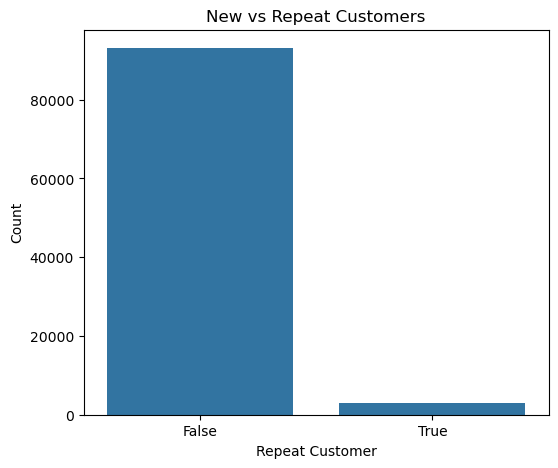

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    141.90
0000b849f77a49e4a4ce2b2a4ca5be3f     27.19
0000f46a3911fa3c0805444483337064     86.22
0000f6ccb0745a6a4b88665a16c9f078     43.62
0004aac84e0df4da2b147fca70cf8255    196.89
Name: total_order_value, dtype: float64


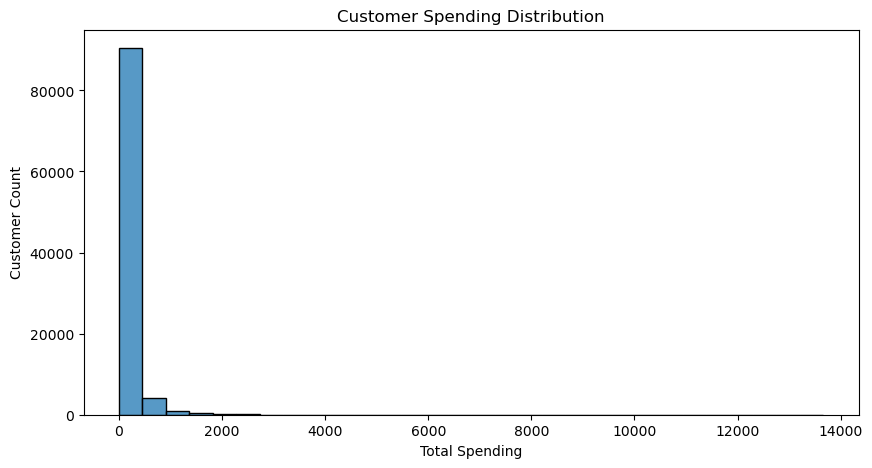

customer_state
SP    50265
RJ    15518
MG    13819
RS     6573
PR     6043
Name: count, dtype: int64


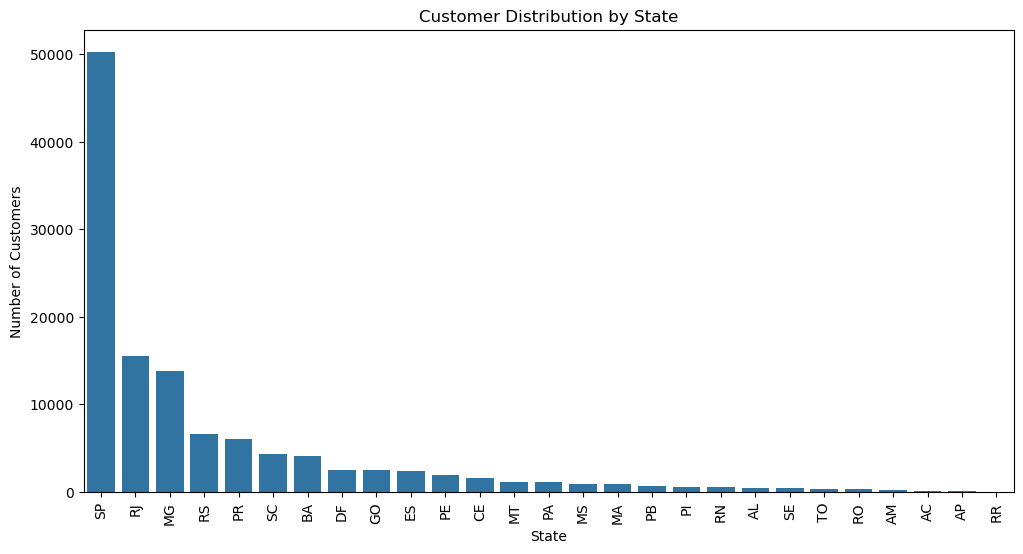

In [26]:
#: EXPLORATORY DATA ANALYSIS (EDA)

#Customer Analysis

#1. New vs Repeat Customers
customer_orders = master_dataset.groupby('customer_unique_id')['order_id'].nunique()

new_customers = (customer_orders == 1).sum()

repeat_customers = (customer_orders > 1).sum()

print("New Customers:", new_customers)

print("Repeat Customers:", repeat_customers)

plt.figure(figsize=(6,5))

sns.countplot(x=(customer_orders > 1))

plt.title("New vs Repeat Customers")

plt.xlabel("Repeat Customer")

plt.ylabel("Count")

plt.show()

#2.High-value vs Low-value Customers
customer_value = master_dataset.groupby('customer_unique_id')['total_order_value'].sum()

print(customer_value.head())

plt.figure(figsize=(10,5))

sns.histplot(customer_value, bins=30)

plt.title("Customer Spending Distribution")

plt.xlabel("Total Spending")

plt.ylabel("Customer Count")

plt.show()


#3.Geographic Distribution of Customers
customer_location = master_dataset['customer_state'].value_counts()

print(customer_location.head())

plt.figure(figsize=(12,6))

sns.barplot(x=customer_location.index,
            y=customer_location.values)

plt.title("Customer Distribution by State")

plt.xlabel("State")

plt.ylabel("Number of Customers")

plt.xticks(rotation=90)

plt.show()


order_month
2016-09       354.75
2016-10     58730.85
2016-12        19.62
2017-01    148030.11
2017-02    303648.31
Freq: M, Name: total_order_value, dtype: float64


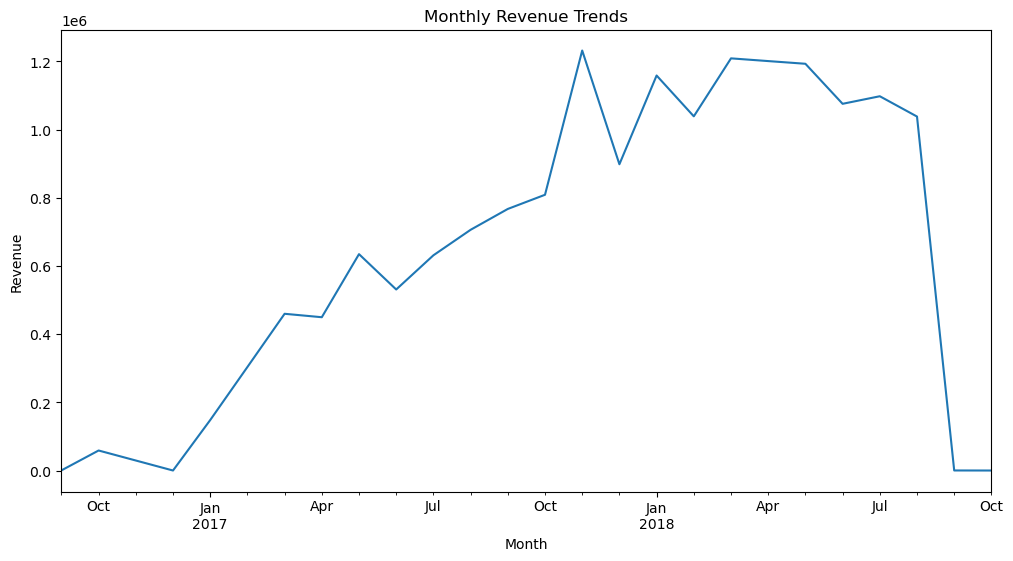

order_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
Freq: M, Name: order_id, dtype: int64


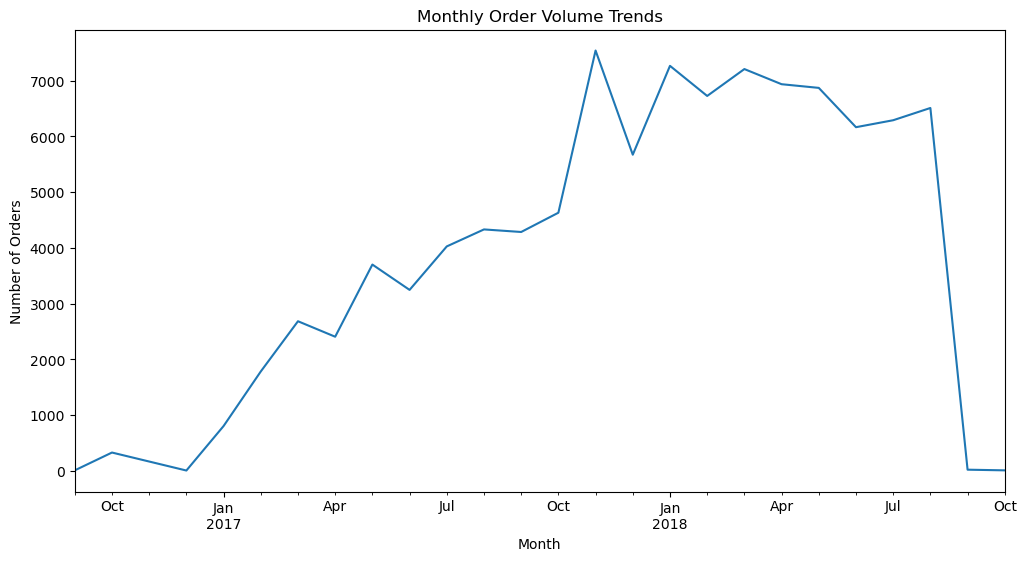

order_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
Freq: M, Name: order_id, dtype: int64


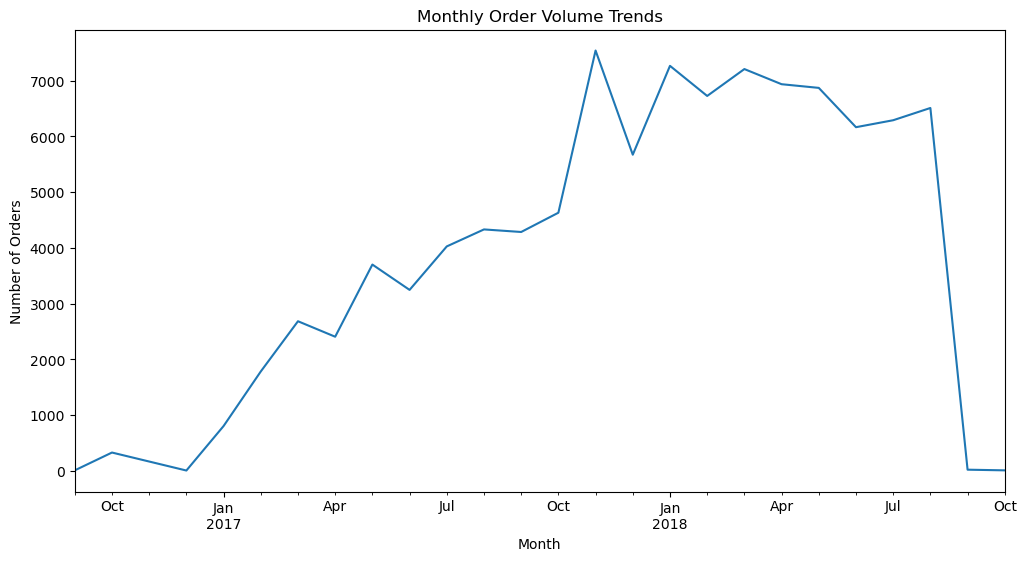

In [27]:
#Revenue and Order Analysis

#1.Monthly revenue trends 
master_dataset['order_month'] = master_dataset['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = master_dataset.groupby('order_month')['total_order_value'].sum()

print(monthly_revenue.head())

plt.figure(figsize=(12,6))

monthly_revenue.plot()

plt.title("Monthly Revenue Trends")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()
#2.Order volume trends 
monthly_orders = master_dataset.groupby('order_month')['order_id'].nunique()

print(monthly_orders.head())

plt.figure(figsize=(12,6))

monthly_orders.plot()

plt.title("Monthly Order Volume Trends")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.show()


#3.Peak sales periods 
monthly_orders = master_dataset.groupby('order_month')['order_id'].nunique()

print(monthly_orders.head())

plt.figure(figsize=(12,6))

monthly_orders.plot()

plt.title("Monthly Order Volume Trends")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.show()


product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: count, dtype: int64


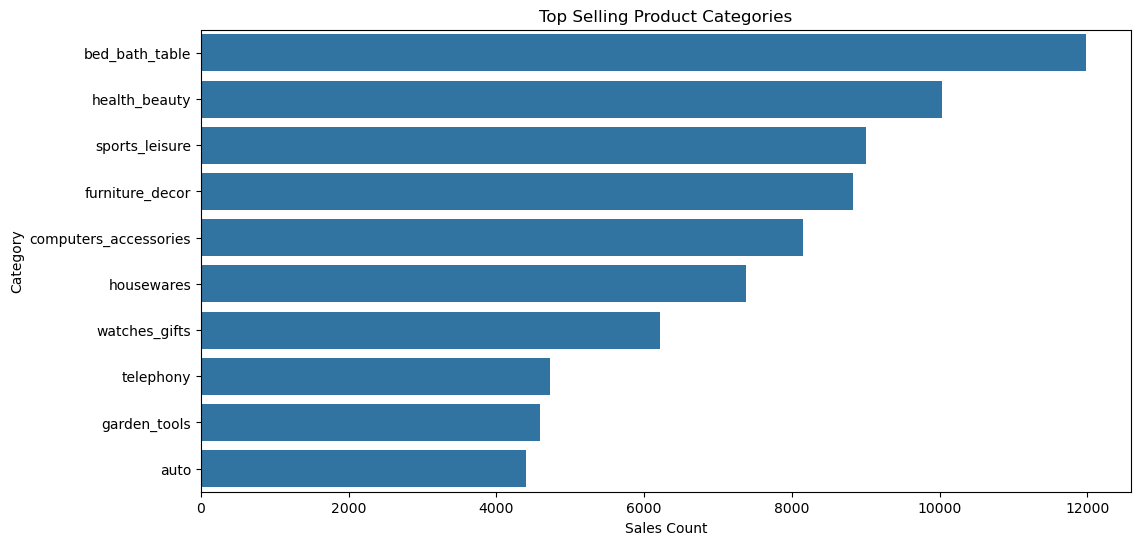

product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: count, dtype: int64


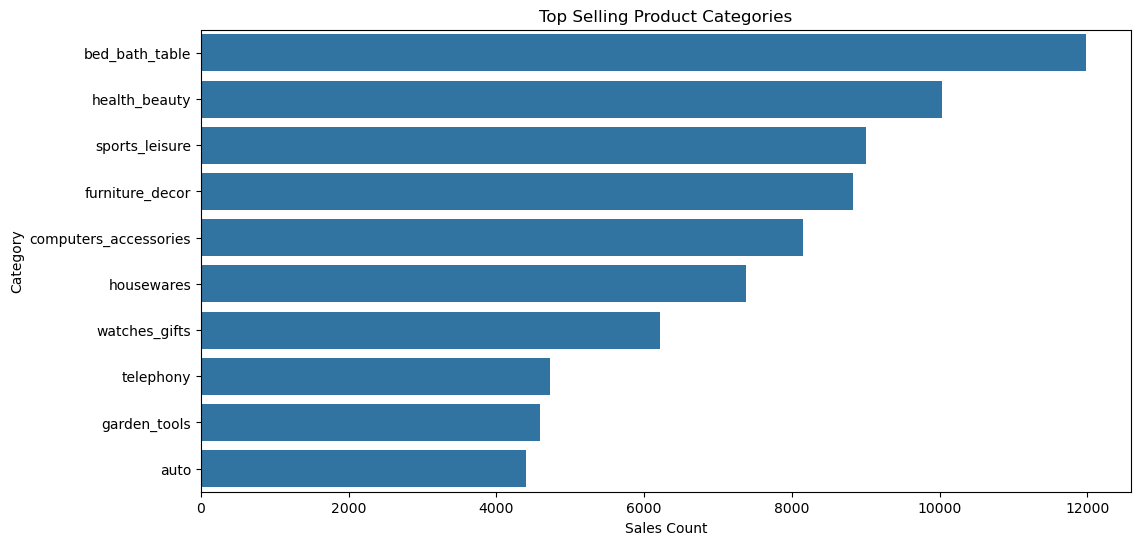

product_category_name_english
health_beauty            1491397.76
watches_gifts            1358845.59
bed_bath_table           1327662.02
sports_leisure           1205197.85
computers_accessories    1104362.03
furniture_decor           955367.22
housewares                823623.50
cool_stuff                752702.21
auto                      714431.95
garden_tools              625387.31
Name: total_order_value, dtype: float64


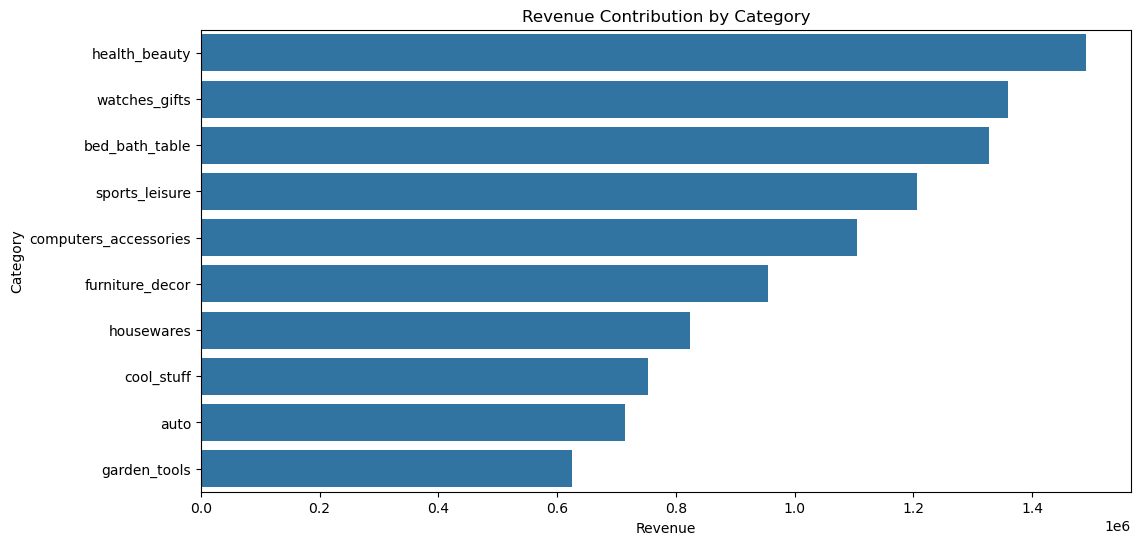

In [29]:
#Product Analysis
#1.Top-selling product categories 
top_categories = master_dataset['product_category_name_english'].value_counts().head(10)

print(top_categories)

plt.figure(figsize=(12,6))

sns.barplot(x=top_categories.values,
            y=top_categories.index)

plt.title("Top Selling Product Categories")

plt.xlabel("Sales Count")

plt.ylabel("Category")

plt.show()


#2.	Revenue contribution by category 
top_categories = master_dataset['product_category_name_english'].value_counts().head(10)

print(top_categories)

plt.figure(figsize=(12,6))

sns.barplot(x=top_categories.values,
            y=top_categories.index)

plt.title("Top Selling Product Categories")

plt.xlabel("Sales Count")

plt.ylabel("Category")

plt.show()


#3.Product demand distribution 
category_revenue = master_dataset.groupby( 'product_category_name_english')['total_order_value'].sum().sort_values(ascending=False).head(10)
print(category_revenue)

plt.figure(figsize=(12,6))

sns.barplot(x=category_revenue.values,
            y=category_revenue.index)

plt.title("Revenue Contribution by Category")

plt.xlabel("Revenue")

plt.ylabel("Category")

plt.show()

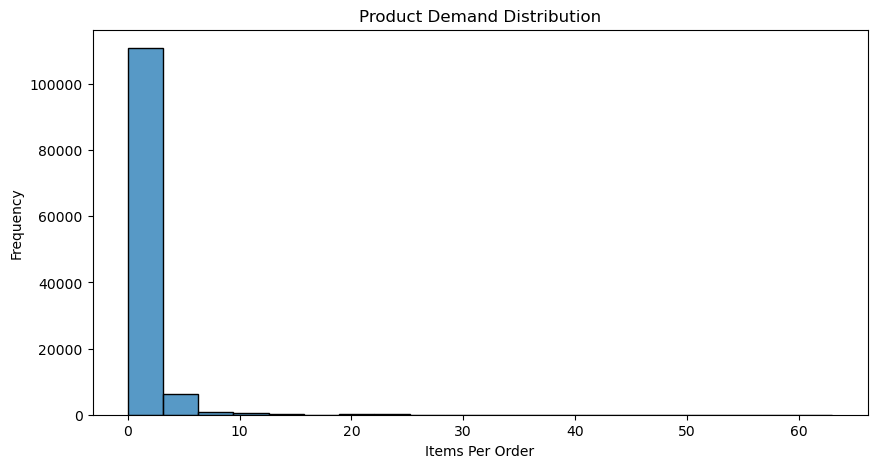

seller_id
53243585a1d6dc2643021fd1853d8905    258882.28
4869f7a5dfa277a7dca6462dcf3b52b2    258625.52
7c67e1448b00f6e969d365cea6b010ab    254387.70
4a3ca9315b744ce9f8e9374361493884    253535.64
fa1c13f2614d7b5c4749cbc52fecda94    214454.82
da8622b14eb17ae2831f4ac5b9dab84a    198621.24
7e93a43ef30c4f03f38b393420bc753a    189475.90
1025f0e2d44d7041d6cf58b6550e0bfa    178696.05
7a67c85e85bb2ce8582c35f2203ad736    172887.23
955fee9216a65b617aa5c0531780ce60    163275.71
Name: total_order_value, dtype: float64


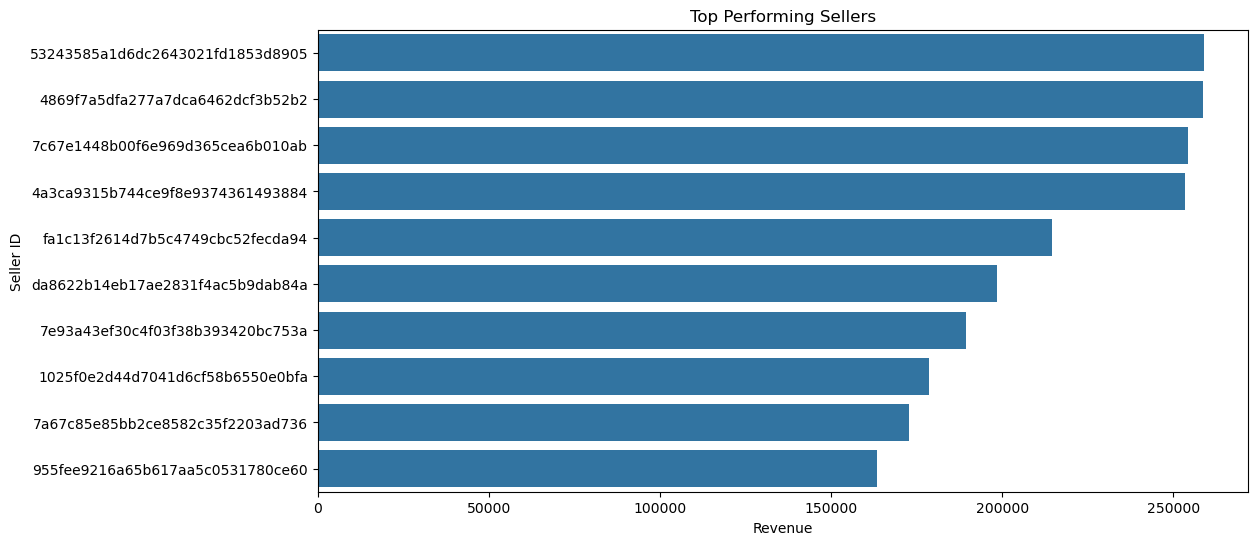

seller_state
AC       299.84
AM      1258.80
BA    343060.90
CE     25169.74
DF    127294.93
Name: total_order_value, dtype: float64


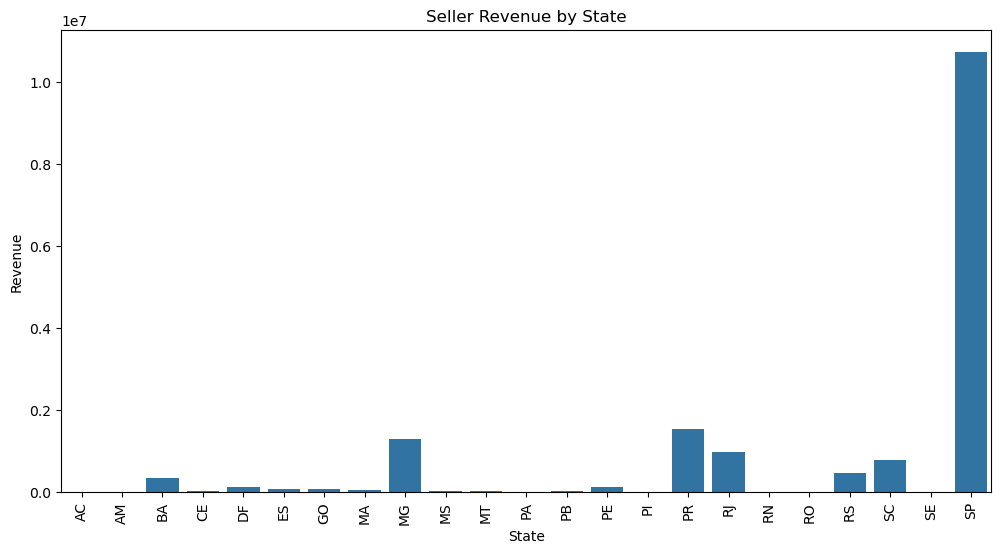

In [30]:
#Seller Analysis
#1.	Top-performing sellers 
plt.figure(figsize=(10,5))

sns.histplot(master_dataset['items_per_order'], bins=20)

plt.title("Product Demand Distribution")

plt.xlabel("Items Per Order")

plt.ylabel("Frequency")

plt.show()
#2.	Seller contribution to revenue 
top_sellers = master_dataset.groupby('seller_id')['total_order_value'].sum().sort_values(ascending=False).head(10)

print(top_sellers)

plt.figure(figsize=(12,6))

sns.barplot(x=top_sellers.values,
            y=top_sellers.index)

plt.title("Top Performing Sellers")

plt.xlabel("Revenue")

plt.ylabel("Seller ID")

plt.show()
#3.Seller distribution 
seller_revenue = master_dataset.groupby('seller_state')['total_order_value'].sum()

print(seller_revenue.head())

plt.figure(figsize=(12,6))

sns.barplot(x=seller_revenue.index, y=seller_revenue.values)
           

plt.title("Seller Revenue by State")

plt.xlabel("State")

plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

review_score
5.0    66343
4.0    22319
1.0    15428
3.0     9894
2.0     4162
Name: count, dtype: int64


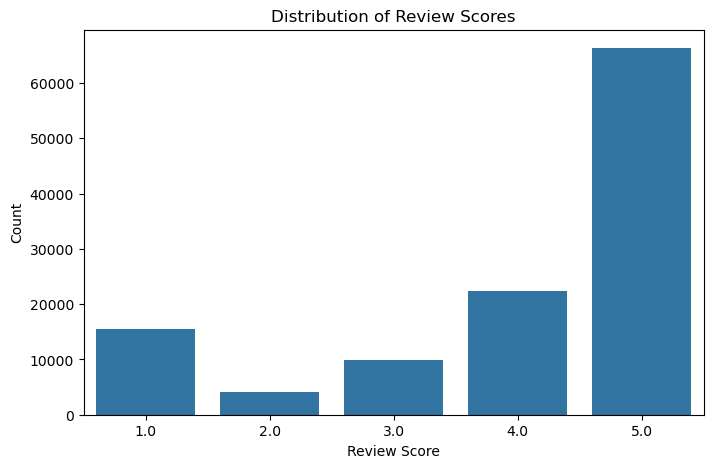

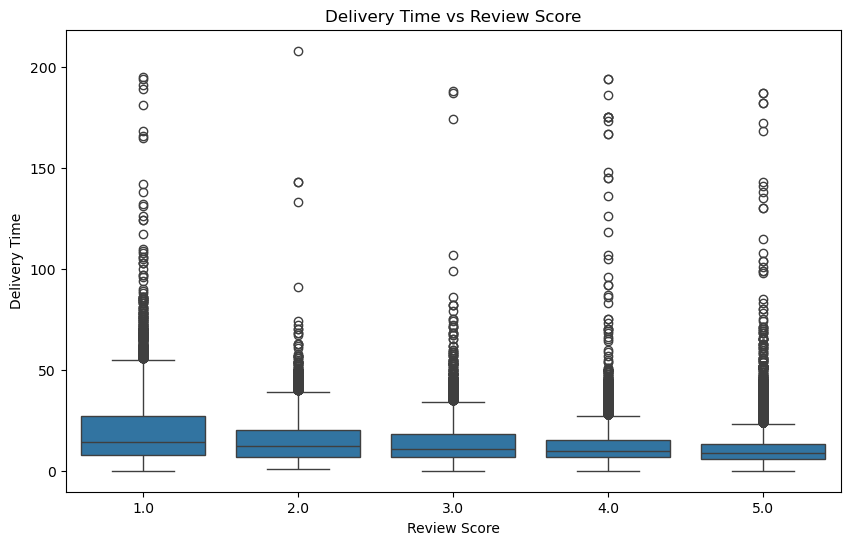

    delivery_time  review_score order_status
8             NaN           2.0     invoiced
10            9.0           1.0    delivered
13           12.0           1.0    delivered
14           12.0           1.0    delivered
26           21.0           2.0    delivered


In [101]:
#Review and Satisfaction Analysis
#1,Distribution of review scores
review_distribution = master_dataset['review_score'].value_counts()

print(review_distribution)

plt.figure(figsize=(8,5))

sns.countplot(x=master_dataset['review_score'])

plt.title("Distribution of Review Scores")

plt.xlabel("Review Score")

plt.ylabel("Count")

plt.show()
#2.Relationship between delivery time and ratings 
plt.figure(figsize=(10,6))

sns.boxplot(x=master_dataset['review_score'],
            y=master_dataset['delivery_time'])

plt.title("Delivery Time vs Review Score")

plt.xlabel("Review Score")

plt.ylabel("Delivery Time")

plt.show()
#3.Identification of dissatisfaction patterns 
low_reviews = master_dataset[
    master_dataset['review_score'] <= 2
]

print(low_reviews[['delivery_time',
                   'review_score',
                   'order_status']].head())

order_month
2016-09       354.75
2016-10     58730.85
2016-12        19.62
2017-01    148030.11
2017-02    303648.31
Freq: M, Name: total_order_value, dtype: float64


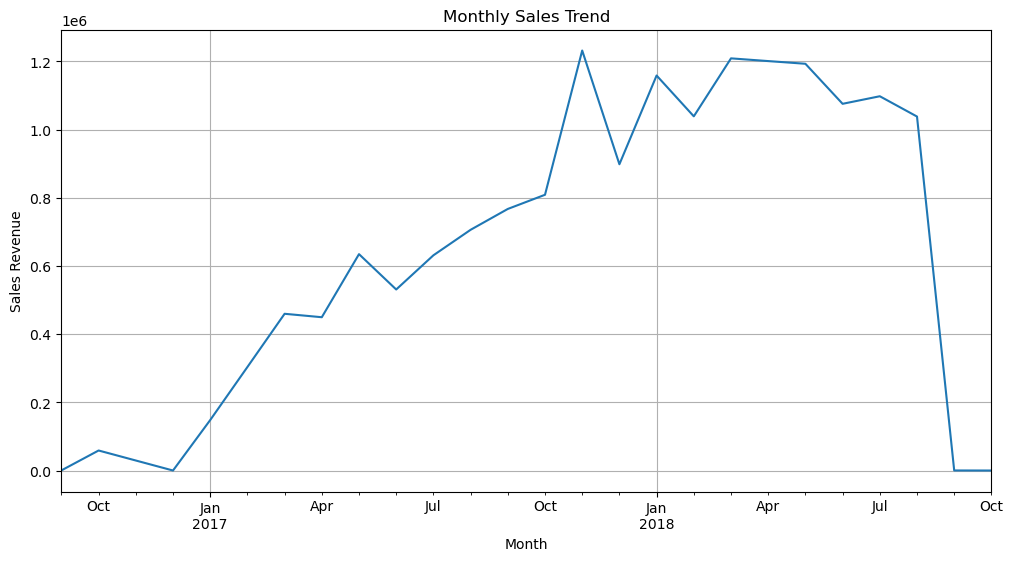

product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: count, dtype: int64


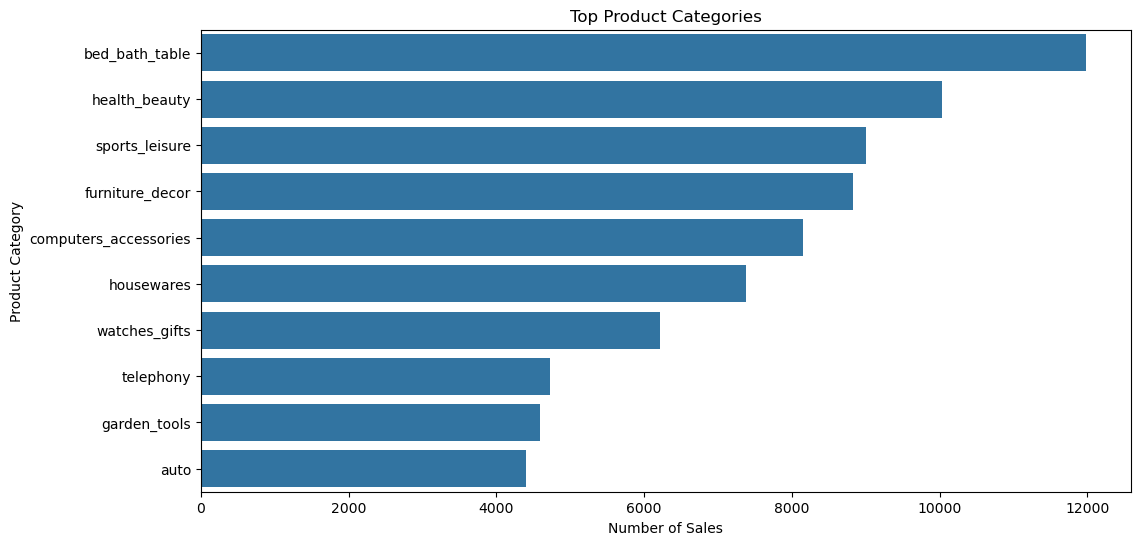

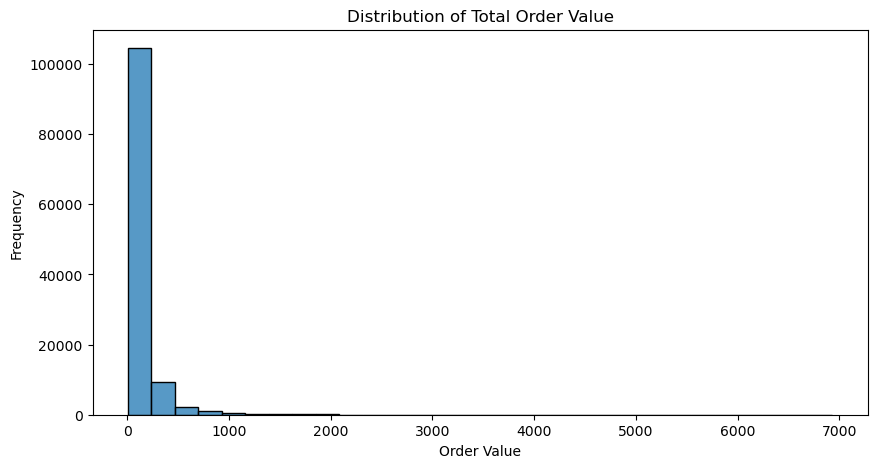

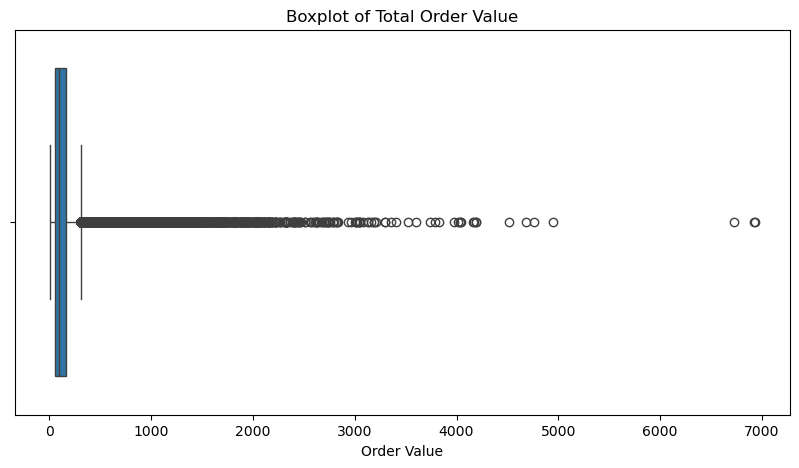

                      price  freight_value  total_order_value  delivery_time  \
price              1.000000       0.415938           0.997160       0.061389   
freight_value      0.415938       1.000000           0.483242       0.212870   
total_order_value  0.997160       0.483242           1.000000       0.076743   
delivery_time      0.061389       0.212870           0.076743       1.000000   
review_score      -0.004492      -0.037013          -0.007407      -0.302750   

                   review_score  
price                 -0.004492  
freight_value         -0.037013  
total_order_value     -0.007407  
delivery_time         -0.302750  
review_score           1.000000  


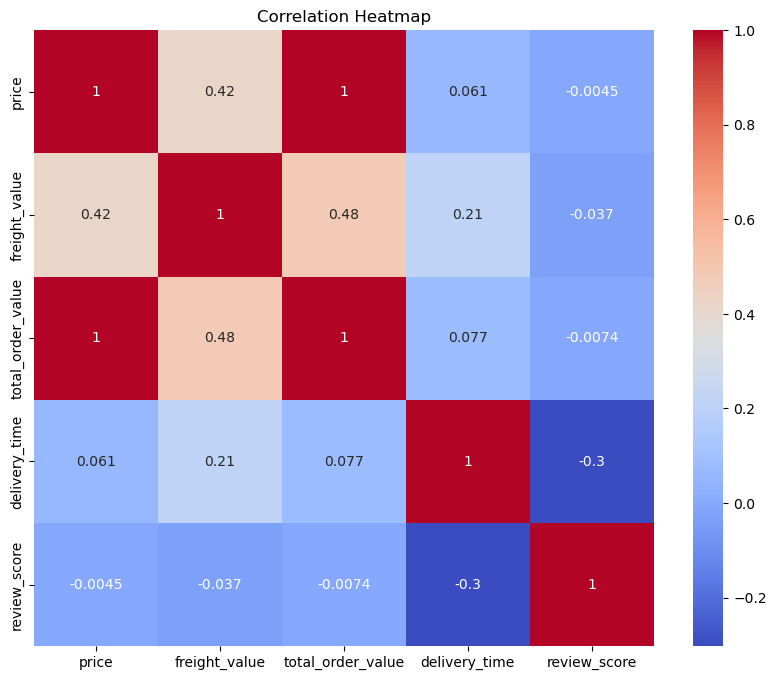

In [31]:
#ADDITIONAL DATA VISUALIZATION
# ------------------------------------------------------------
#1. Time Series Plot (Monthly Sales Trend)
# ------------------------------------------------------------
master_dataset['order_month'] = master_dataset[
    'order_purchase_timestamp'
].dt.to_period('M')

monthly_sales = master_dataset.groupby(
    'order_month'
)['total_order_value'].sum()

print(monthly_sales.head())

plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales Revenue")

plt.grid(True)

plt.show()
# ------------------------------------------------------------
#2. Bar Chart (Top Product Categories)
# ------------------------------------------------------------
top_categories = master_dataset[
    'product_category_name_english'
].value_counts().head(10)

print(top_categories)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top Product Categories")

plt.xlabel("Number of Sales")

plt.ylabel("Product Category")

plt.show()


# ------------------------------------------------------------
## 3. Histogram (Order Value Distribution)
# ------------------------------------------------------------
plt.figure(figsize=(10,5))

sns.histplot(
    master_dataset['total_order_value'],
    bins=30
)

plt.title("Distribution of Total Order Value")

plt.xlabel("Order Value")

plt.ylabel("Frequency")

plt.show()



# ------------------------------------------------------------
# 4. Box Plot (Outlier Detection)
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

sns.boxplot(
    x=master_dataset['total_order_value']
)

plt.title("Boxplot of Total Order Value")

plt.xlabel("Order Value")

plt.show()



# ------------------------------------------------------------
# 5. Heatmap (Correlation Analysis)
# ------------------------------------------------------------

correlation = master_dataset[
    [
        'price',
        'freight_value',
        'total_order_value',
        'delivery_time',
        'review_score'
    ]].corr()


print(correlation)

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()